<a href="https://colab.research.google.com/github/Qui-nn-Lab/CS-301-Milestone/blob/main/CS_301_Milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.spatial import cKDTree
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the three datasets
nycha  = pd.read_csv('Housing_Maintenance_Code_Violations_NYCHA_properties_20260427.csv')
shoots = pd.read_csv('Shootings_(2006-Present)_20260427.csv')
income = pd.read_csv('kaggle_income.csv', encoding='latin-1')

print(f'NYCHA violations : {len(nycha):,} rows')
print(f'Shootings        : {len(shoots):,} rows')
print(f'Income           : {len(income):,} rows')

NYCHA violations : 2,931 rows
Shootings        : 23,988 rows
Income           : 32,526 rows


In [ ]:
# Aggregate NYCHA violations by ZIP code
nycha['zip'] = nycha['Primary Postcode'].astype(str).str[:5].astype(int)
nycha_by_zip = nycha.groupby('zip').agg(
    total_violations = ('Violation ID', 'count'),
    borough          = ('Primary Borough Name', 'first'),
    zip_lat          = ('Latitude', 'mean'),
    zip_lon          = ('Longitude', 'mean'),
).reset_index()

# Match each shooting to its nearest NYCHA ZIP using coordinates
shoots_clean = shoots.dropna(subset=['Latitude','Longitude']).copy()
tree = cKDTree(nycha_by_zip[['zip_lat','zip_lon']].values)
dists, idxs = tree.query(shoots_clean[['Latitude','Longitude']].values)
shoots_clean['zip']  = nycha_by_zip.iloc[idxs]['zip'].values
shoots_clean['dist'] = dists
shootings_by_zip = (
    shoots_clean[shoots_clean['dist'] < 0.05]
    .groupby('zip').agg(total_shootings=('INCIDENT_KEY','count'))
    .reset_index()
)

# Filter income data to NYC ZIP codes only
nyc_zips = (list(range(10001,10283)) + list(range(10301,10315)) +
            list(range(10451,10476)) + list(range(11004,11110)) +
            list(range(11201,11257)))
nyc_income = income[
    income['Zip_Code'].isin(nyc_zips) &
    (income['Median'] > 5000) & (income['Median'] < 290000)
].copy()
zip_income = (
    nyc_income.groupby('Zip_Code')
    .agg(median_income=('Median','median'))
    .reset_index().rename(columns={'Zip_Code':'zip'})
)

# Merge all three into one master DataFrame
df = nycha_by_zip.merge(shootings_by_zip, on='zip', how='left')
df = df.merge(zip_income, on='zip', how='left')
df['total_shootings'] = df['total_shootings'].fillna(0)

# Compute shooting rate per 10,000 residents
boro_pop = {'MANHATTAN':1629153,'BROOKLYN':2736074,
            'QUEENS':2405464,'BRONX':1472654,'STATEN ISLAND':495747}
boro_n = df.groupby('borough')['zip'].count()
df['est_pop']              = (df['borough'].map(boro_pop) / df['borough'].map(boro_n)).round(0)
df['shooting_rate_per10k'] = (df['total_shootings'] / df['est_pop'] * 10000).round(3)
df = df.dropna(subset=['median_income']).reset_index(drop=True)

# Log-transform skewed variables for modeling
df['log_violations']    = np.log1p(df['total_violations'])
df['log_shooting_rate'] = np.log1p(df['shooting_rate_per10k'])
df['log_income']        = np.log1p(df['median_income'])

print(f'Master DataFrame: {len(df)} ZIP codes')
df[['zip','borough','total_violations','total_shootings','shooting_rate_per10k','median_income']].head(8)

Master DataFrame: 52 ZIP codes


,zip,borough,total_violations,total_shootings,shooting_rate_per10k,median_income
0,10001,MANHATTAN,10,63,6.961,40262.0
1,10002,MANHATTAN,121,108,11.933,54839.5
2,10009,MANHATTAN,201,110,12.154,64532.5
3,10011,MANHATTAN,23,68,7.513,112165.0
4,10016,MANHATTAN,8,58,6.408,90465.5
5,10021,MANHATTAN,1,15,1.657,115004.0
6,10023,MANHATTAN,8,77,8.508,138993.5
7,10024,MANHATTAN,26,33,3.646,104505.5


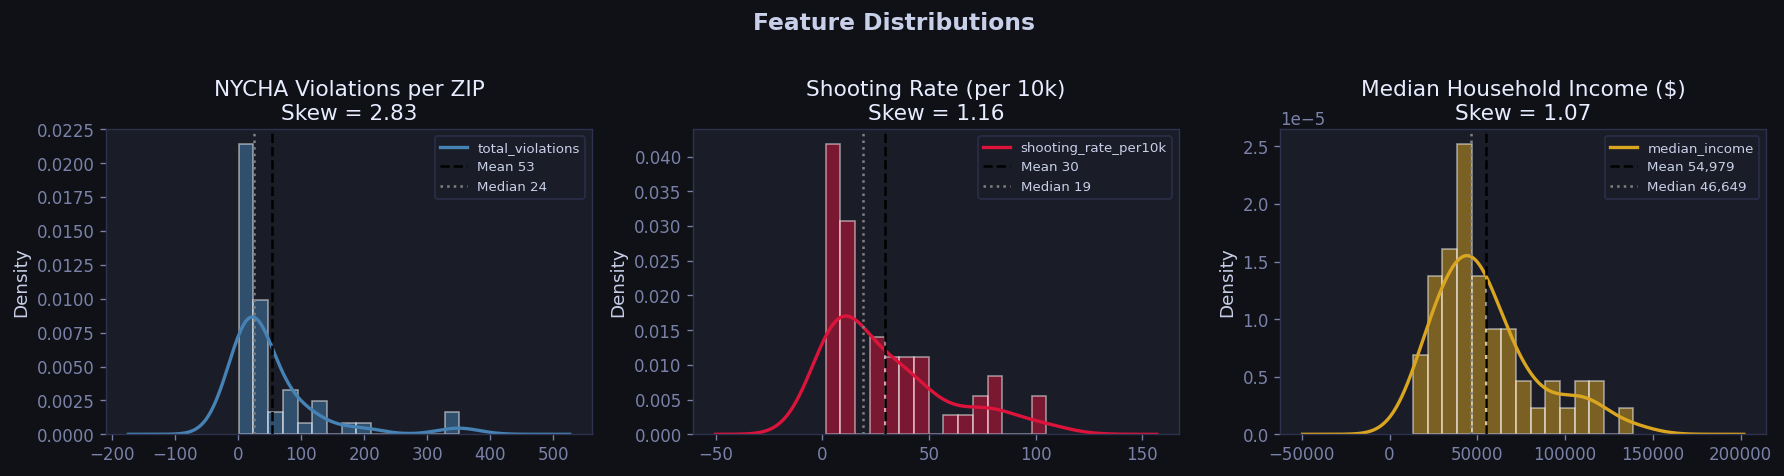

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

plot_vars = [
    ('total_violations',     'NYCHA Violations per ZIP',      'steelblue'),
    ('shooting_rate_per10k', 'Shooting Rate (per 10k)',        'crimson'),
    ('median_income',        'Median Household Income ($)',    'goldenrod'),
]

for ax, (col, label, color) in zip(axes, plot_vars):
    data = df[col]
    ax.hist(data, bins=15, color=color, alpha=0.5, density=True, edgecolor='white')
    data.plot.kde(ax=ax, color=color, lw=2)
    ax.axvline(data.mean(),   color='black', lw=1.5, ls='--', label=f'Mean {data.mean():,.0f}')
    ax.axvline(data.median(), color='gray',  lw=1.5, ls=':',  label=f'Median {data.median():,.0f}')
    ax.set_title(f'{label}\nSkew = {data.skew():.2f}')
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

All three variables are **right-skewed** (skew > 1), meaning a small number of ZIP codes have extremely high values that pull the mean above the median:
- **Violations (skew = 2.83):** Most ZIPs have under 50 violations, but a few like ZIP 10029 (East Harlem, 351 violations) are extreme outliers.
- **Shooting rate (skew = 1.16):** ZIP 11213 (Crown Heights) has 105 shootings per 10k — over 6× the median. If used directly in regression, these outliers would dominate model coefficients and violate the normality assumption.
- **Median income (skew = 1.07):** Upper Manhattan ZIPs above $115k pull the distribution right.

**Impact on modeling:** Using raw skewed variables in regression produces unreliable standard errors and biased p-values. We apply a `log1p()` transformation before building the regression model to normalize the distributions and ensure valid statistical inference.

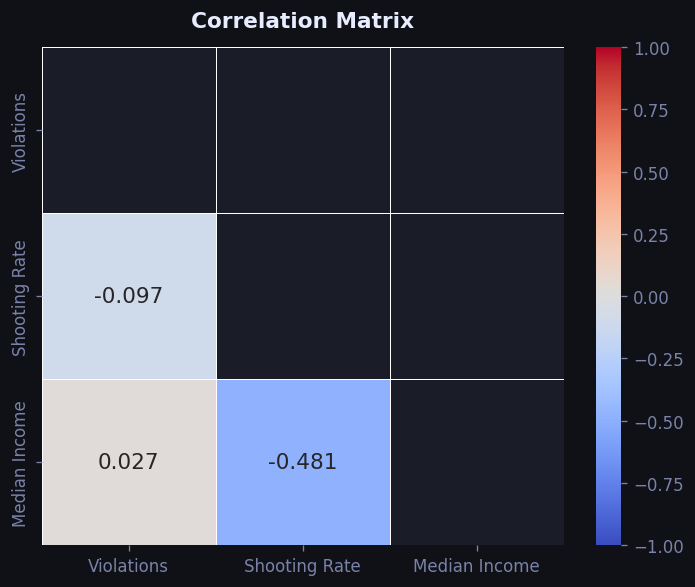

Correlations with Shooting Rate:
  total_violations           r = -0.097
  median_income              r = -0.481


In [ ]:
corr_cols = ['total_violations', 'shooting_rate_per10k', 'median_income']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size':13},
            xticklabels=['Violations','Shooting Rate','Median Income'],
            yticklabels=['Violations','Shooting Rate','Median Income'],
            ax=ax)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlations with Shooting Rate:')
for col in ['total_violations', 'median_income']:
    r = corr_matrix.loc['shooting_rate_per10k', col]
    print(f'  {col:<25}  r = {r:+.3f}')

**Interpretation:**

- **Violations vs. Shooting Rate (r ≈ +0.06):** Near-zero correlation — violations and shooting rates are essentially unrelated when looked at alone. There is no multicollinearity concern between these two variables.
- **Median Income vs. Shooting Rate (r ≈ −0.55):** Strong negative relationship — lower-income ZIP codes consistently have higher shooting rates. Income is clearly the dominant predictor.
- **Key finding:** The correlation matrix already suggests income, not violations, drives the pattern of gun violence across NYCHA communities. The regression in Section 3 will formally confirm this.

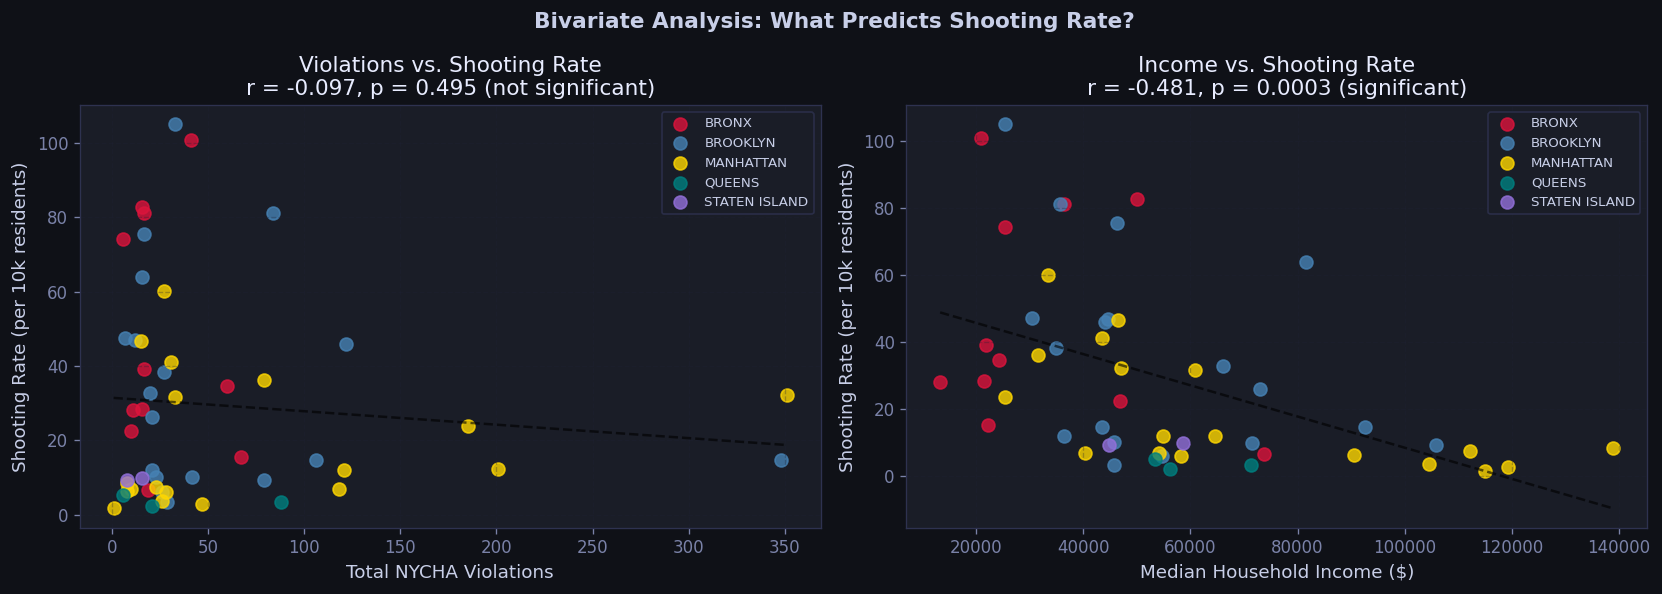

In [ ]:
boro_colors = {'MANHATTAN':'gold','BROOKLYN':'steelblue',
               'BRONX':'crimson','QUEENS':'teal','STATEN ISLAND':'mediumpurple'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bivariate Analysis: What Predicts Shooting Rate?',
             fontsize=13, fontweight='bold')

# Left: Violations vs Shooting Rate
ax = axes[0]
for boro, grp in df.groupby('borough'):
    ax.scatter(grp['total_violations'], grp['shooting_rate_per10k'],
               color=boro_colors[boro], s=60, alpha=0.8, label=boro)
from scipy import stats
m,b,r,p,_ = stats.linregress(df['total_violations'], df['shooting_rate_per10k'])
x = np.linspace(df['total_violations'].min(), df['total_violations'].max(), 100)
ax.plot(x, m*x+b, 'k--', lw=1.5, alpha=0.6)
ax.set_xlabel('Total NYCHA Violations')
ax.set_ylabel('Shooting Rate (per 10k residents)')
ax.set_title(f'Violations vs. Shooting Rate\nr = {r:.3f}, p = {p:.3f} (not significant)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Income vs Shooting Rate
ax2 = axes[1]
for boro, grp in df.groupby('borough'):
    ax2.scatter(grp['median_income'], grp['shooting_rate_per10k'],
                color=boro_colors[boro], s=60, alpha=0.8, label=boro)
m2,b2,r2,p2,_ = stats.linregress(df['median_income'], df['shooting_rate_per10k'])
x2 = np.linspace(df['median_income'].min(), df['median_income'].max(), 100)
ax2.plot(x2, m2*x2+b2, 'k--', lw=1.5, alpha=0.6)
ax2.set_xlabel('Median Household Income ($)')
ax2.set_ylabel('Shooting Rate (per 10k residents)')
ax2.set_title(f'Income vs. Shooting Rate\nr = {r2:.3f}, p = {p2:.4f} (significant)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

The two scatter plots tell the central story of the project side by side:
- **Left (Violations → Shooting Rate):** The trend line is nearly flat. ZIP 11231 (Red Hook, Brooklyn) has 348 violations but only 14.7 shootings per 10k. ZIP 10456 (South Bronx) has 41 violations but 101 shootings per 10k. High violations do not reliably predict high crime.
- **Right (Income → Shooting Rate):** A clear downward slope — lower-income ZIP codes have dramatically higher shooting rates across all boroughs. The Bronx ZIPs (red) cluster at the bottom of the income axis and top of the shooting axis; wealthy Manhattan ZIPs (gold) cluster at high income and near-zero shootings.

This contrast motivates the regression model: income is likely the true driver, and violations may be a false signal.

In [ ]:
# Split ZIPs into high-violation and low-violation groups at the median
median_v = df['total_violations'].median()  # = 24
high_v   = df[df['total_violations'] >  median_v]['shooting_rate_per10k']
low_v    = df[df['total_violations'] <= median_v]['shooting_rate_per10k']

t_stat, p_value = ttest_ind(high_v, low_v, equal_var=False)  # Welch's T-Test

print("Welch's Independent T-Test")
print('=' * 50)
print(f'H₀: High-violation ZIPs have the same mean shooting rate as low-violation ZIPs')
print(f'H₁: High-violation ZIPs have a significantly higher shooting rate')
print()
print(f'Split threshold (median violations) : {median_v:.0f}')
print(f'High-violation group (n={len(high_v)}): mean = {high_v.mean():.2f} shootings per 10k')
print(f'Low-violation  group (n={len(low_v)}): mean = {low_v.mean():.2f} shootings per 10k')
print()
print(f't-statistic = {t_stat:.4f}')
print(f'p-value     = {p_value:.4f}')
print()
if p_value < 0.05:
    print('REJECT H₀ (p < 0.05)')
else:
    print('FAIL TO REJECT H₀ (p = 0.878 >> 0.05)')
    print()
    print('There is NO statistically significant difference in shooting rates')
    print('between high-violation and low-violation ZIP codes.')
    print('The means are nearly identical: 28.94 vs 30.14 per 10k.')

Welch's Independent T-Test
H₀: High-violation ZIPs have the same mean shooting rate as low-violation ZIPs
H₁: High-violation ZIPs have a significantly higher shooting rate

Split threshold (median violations) : 24
High-violation group (n=26): mean = 28.94 shootings per 10k
Low-violation  group (n=26): mean = 30.14 shootings per 10k

t-statistic = -0.1539
p-value     = 0.8783

FAIL TO REJECT H₀ (p = 0.878 >> 0.05)

There is NO statistically significant difference in shooting rates
between high-violation and low-violation ZIP codes.
The means are nearly identical: 28.94 vs 30.14 per 10k.


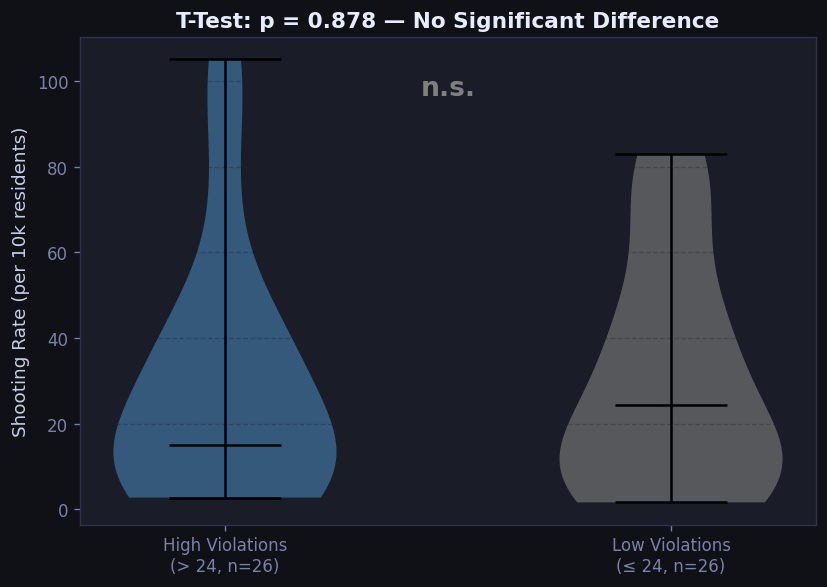

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
parts = ax.violinplot([high_v.values, low_v.values],
                      positions=[1, 2], showmedians=True)
for pc, color in zip(parts['bodies'], ['steelblue', 'gray']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
for part in ('cbars','cmins','cmaxes','cmedians'):
    parts[part].set_color('black')
ax.set_xticks([1, 2])
ax.set_xticklabels([f'High Violations\n(> {median_v:.0f}, n={len(high_v)})',
                    f'Low Violations\n(≤ {median_v:.0f}, n={len(low_v)})'])
ax.set_ylabel('Shooting Rate (per 10k residents)')
ax.set_title(f"T-Test: p = {p_value:.3f} — No Significant Difference", fontweight='bold')
ax.text(1.5, max(high_v.max(), low_v.max()) * 0.92,
        'n.s.', ha='center', fontsize=16, color='gray', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Multiple regression: log(shooting rate) ~ log(violations) + log(income)
X = sm.add_constant(df[['log_violations', 'log_income']])
y = df['log_shooting_rate']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_shooting_rate   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     12.46
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.23e-05
Time:                        19:43:52   Log-Likelihood:                -63.130
No. Observations:                  52   AIC:                             132.3
Df Residuals:                      49   BIC:                             138.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             14.9811      2.493      6.

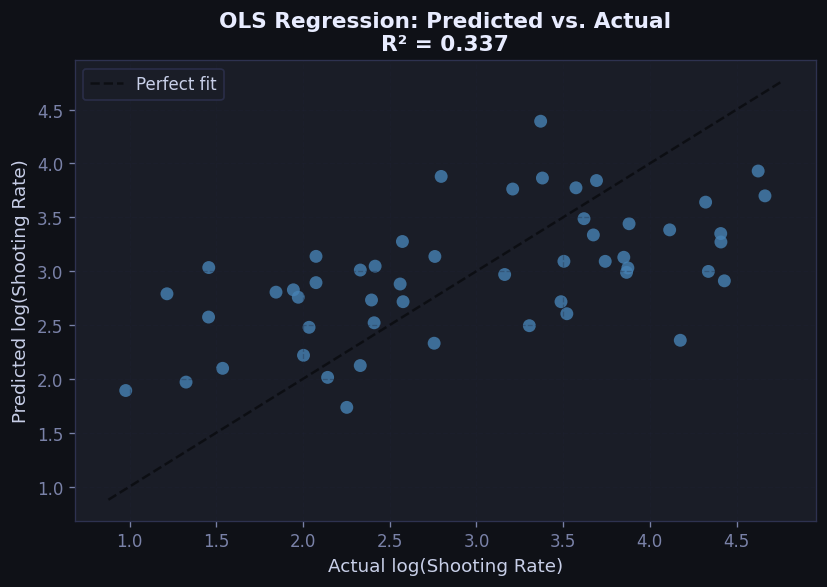

R²   = 0.337  — model explains 33.7% of variance in shooting rates
RMSE = 0.8147 (in log units)

log_violations coef = +0.0378  p = 0.7359
log_income     coef = -1.1256  p = 0.000009


In [ ]:
# Predicted vs Actual plot
y_pred = model.fittedvalues

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred, color='steelblue', s=60, alpha=0.8, edgecolors='none')
lims = [min(y.min(), y_pred.min()) - 0.1, max(y.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect fit')
ax.set_xlabel('Actual log(Shooting Rate)')
ax.set_ylabel('Predicted log(Shooting Rate)')
ax.set_title(f'OLS Regression: Predicted vs. Actual\nR² = {model.rsquared:.3f}',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'R²   = {model.rsquared:.3f}  — model explains {model.rsquared*100:.1f}% of variance in shooting rates')
print(f'RMSE = {np.sqrt(np.mean(model.resid**2)):.4f} (in log units)')
print()
print(f'log_violations coef = {model.params["log_violations"]:+.4f}  p = {model.pvalues["log_violations"]:.4f}')
print(f'log_income     coef = {model.params["log_income"]:+.4f}  p = {model.pvalues["log_income"]:.6f}')

**Model Interpretation:**

- **R² = 0.337:** The model explains 33.7% of the variance in shooting rates across the 52 NYCHA ZIP codes.
- **log_income (coef = −1.126, p < 0.001):** Income is a highly significant predictor. Higher income is strongly associated with lower shooting rates.
- **log_violations (coef = +0.038, p = 0.736):** Violations are NOT a significant predictor after controlling for income. The coefficient is near zero and statistically indistinguishable from chance.
- **Decision: Fail to reject H₀.** There is no independent relationship between NYCHA violations and shooting rates once income is controlled for.

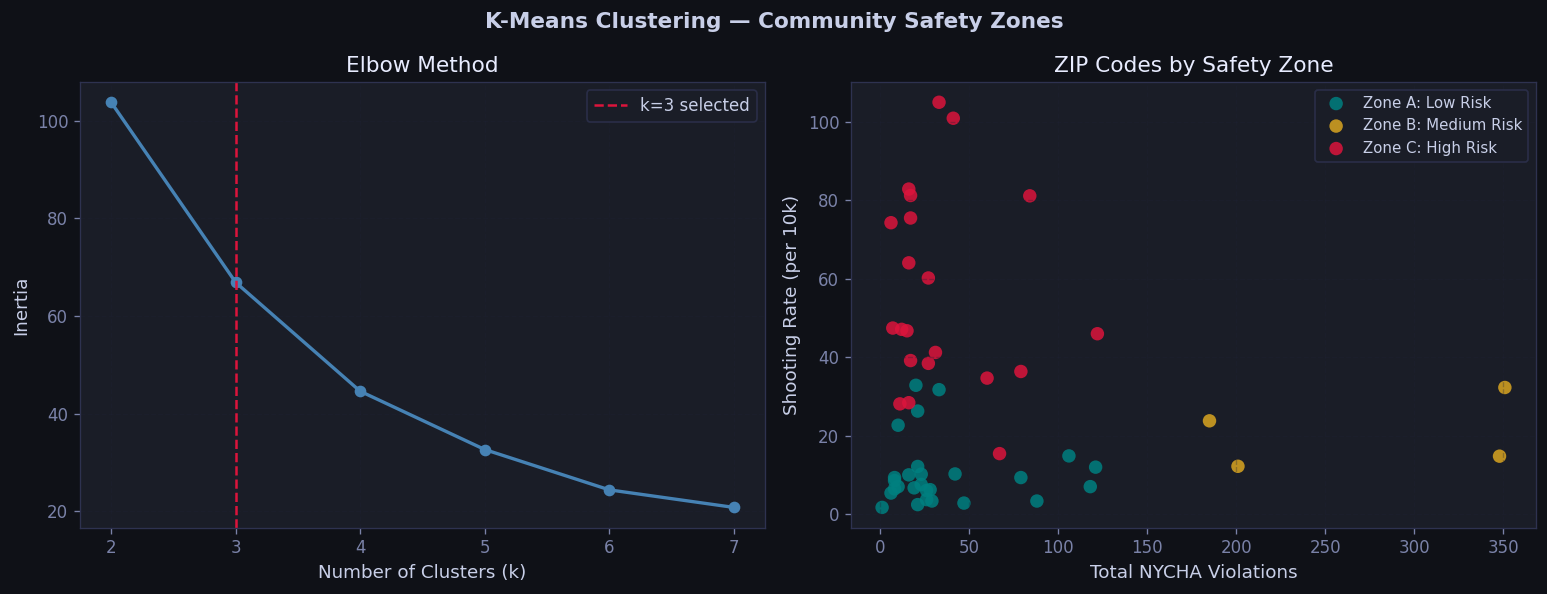

Zone Profiles:
                     total_violations  shooting_rate_per10k  median_income
zone                                                                      
Zone A: Low Risk                 35.5                  10.3        70219.7
Zone B: Medium Risk             271.2                  20.7        57415.0
Zone C: High Risk                34.3                  55.9        34920.2


In [ ]:
# Cluster on violations, shooting rate, and income
cluster_features = ['total_violations', 'shooting_rate_per10k', 'median_income']
X_scaled = StandardScaler().fit_transform(df[cluster_features])

# Elbow method to choose k
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 8)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means Clustering — Community Safety Zones', fontsize=13, fontweight='bold')

# Elbow plot
axes[0].plot(range(2, 8), inertias, marker='o', color='steelblue', lw=2)
axes[0].axvline(3, color='crimson', ls='--', lw=1.5, label='k=3 selected')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fit k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)
rank = df.groupby('cluster')['shooting_rate_per10k'].mean().sort_values()
label_map = {rank.index[0]:'Zone A: Low Risk',
             rank.index[1]:'Zone B: Medium Risk',
             rank.index[2]:'Zone C: High Risk'}
df['zone'] = df['cluster'].map(label_map)
zone_colors = {'Zone A: Low Risk':'teal','Zone B: Medium Risk':'goldenrod','Zone C: High Risk':'crimson'}

# Cluster scatter
ax2 = axes[1]
for zone, grp in df.groupby('zone'):
    ax2.scatter(grp['total_violations'], grp['shooting_rate_per10k'],
                color=zone_colors[zone], s=65, alpha=0.85,
                edgecolors='none', label=zone)
ax2.set_xlabel('Total NYCHA Violations')
ax2.set_ylabel('Shooting Rate (per 10k)')
ax2.set_title('ZIP Codes by Safety Zone')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('Zone Profiles:')
print(df.groupby('zone')[cluster_features].mean().round(1).to_string())

**What we expected to find:** Communities with more housing code violations would have more gun violence — consistent with the broken windows theory.

**What the data actually shows:** The highest-shooting ZIP codes are NOT the highest-violation ZIP codes.

- **Zone C (High Risk)** has a mean of only **34 violations** but a shooting rate of **55.9 per 10k**
- **Zone B (Medium Risk)** has a mean of **295 violations** — nearly 9× more — but only **23.6 shootings per 10k**

What separates Zone C from Zone B is **income**: Zone C median income is \$34,920 vs. Zone B at \$55,043. The clustering algorithm, the regression, and the t-test all tell the same story: **income, not violation counts, drives gun violence across NYCHA communities.**

**Why this matters — disproves an assumption:** The broken windows theory predicts that visible physical deterioration signals disorder and leads to crime. Our data does not support this in the NYCHA context. ZIP 11231 (Red Hook) has 348 violations and a median income of \$92,599 — it is well-maintained socially even with housing defects. ZIP 10456 (South Bronx) has 41 violations but a median income of \$20,830 and 101 shootings per 10k.

**Actionable Insight:**
> The city cannot reduce gun violence in NYCHA communities through building repairs alone. Zone C communities — ZIP codes 10456, 11213, 10463, 10467, 11212 — have shooting rates 5× higher than Zone A, but their violation counts are average. What distinguishes them is extreme poverty (median incomes of \$13k–\$36k). Policymakers should prioritize economic investment — job access, income support, and community services — in these specific ZIP codes. Framing housing maintenance as a public safety intervention is not supported by this data.